# Gaussian Low Pass Filter (GLPF) — Step by Step
> Demonstrates frequency domain filtering using Gaussian filter in Python
>
> **Key difference from Butterworth & Ideal LPF:**  
> Gaussian uses a **bell-curve (Gaussian) roll-off** — the smoothest possible transition.  
> Its Fourier transform is also Gaussian, so **zero ringing**, ever.
>
> ### Formula:
> $$H(u,v) = e^{-D(u,v)^2 \; / \; 2D_0^2}$$
> - **D(u,v)** = distance from DC centre to point (u,v)  
> - **D₀** = cutoff frequency (standard deviation of the Gaussian)

In [1]:
%pip install numpy matplotlib opencv-python Pillow -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

%matplotlib inline
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#0d1117'
plt.rcParams['text.color']       = '#e6edf3'
plt.rcParams['axes.labelcolor']  = '#8b949e'
plt.rcParams['xtick.color']      = '#484f58'
plt.rcParams['ytick.color']      = '#484f58'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['grid.color']       = '#21262d'

print('✅ Libraries loaded')

✅ Libraries loaded


## Step 1 — Load & Display the Original Image

Image size: 224 × 280 px


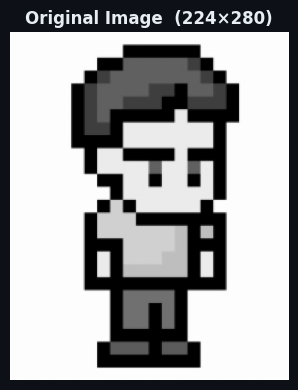

In [3]:
IMAGE_PATH = 'image.png'   # <-- change path if needed

img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE).astype(np.float32)
H, W = img.shape
print(f'Image size: {W} × {H} px')

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img, cmap='gray')
ax.set_title(f'Original Image  ({W}×{H})', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 2 — Compute 2D DFT & Shift Zero-Frequency to Center

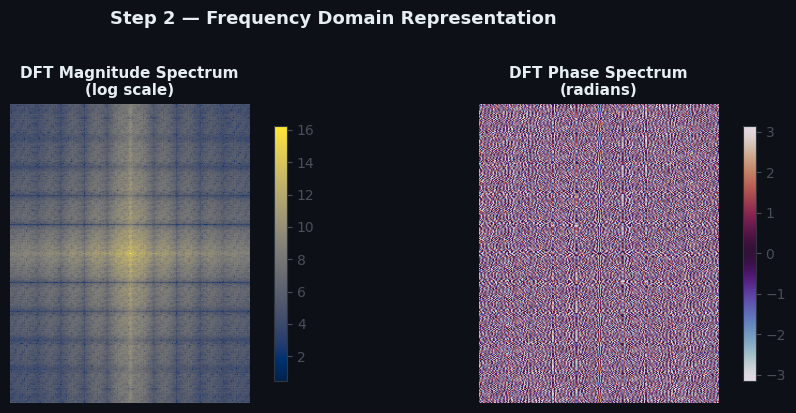

💡 Bright center  = low frequencies (smooth/flat regions)
💡 Bright corners = high frequencies (sharp edges, fine detail)


In [4]:
dft       = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

magnitude = np.abs(dft_shift)
log_mag   = np.log1p(magnitude)
phase     = np.angle(dft_shift)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(log_mag, cmap='cividis')
axes[0].set_title('DFT Magnitude Spectrum\n(log scale)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('low ← frequency → high')
plt.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(phase, cmap='twilight')
axes[1].set_title('DFT Phase Spectrum\n(radians)', fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=axes[1], shrink=0.85)

for ax in axes: ax.axis('off')

plt.suptitle('Step 2 — Frequency Domain Representation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Bright center  = low frequencies (smooth/flat regions)')
print('💡 Bright corners = high frequencies (sharp edges, fine detail)')

## Step 3 — Build the Gaussian LPF Mask

$$H(u,v) = e^{-D^2 / 2D_0^2}$$

- At **D = 0** (DC centre): H = 1.0 → fully passed  
- At **D = D₀**: H = e^(−0.5) ≈ 0.607 → the −3dB / half-power point  
- As **D → ∞**: H → 0 → completely blocked (but smoothly!)

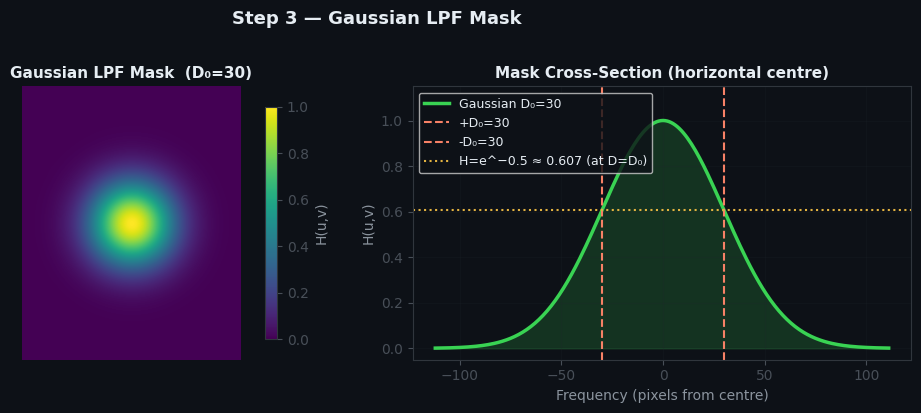

💡 The Gaussian curve has NO hard cutoff and NO parameter like order n.
💡 At D=D₀=30, H = e^(−0.5) ≈ 0.6065  (NOT 0.5 like Butterworth!)
💡 The Fourier transform of a Gaussian is also a Gaussian → zero ringing ever.


In [5]:
def gaussian_lpf_mask(shape, D0):
    """
    Gaussian LPF mask.
    H(u,v) = exp( -D(u,v)^2 / (2 * D0^2) )
    Values range 0.0 → 1.0 with perfectly smooth bell-curve roll-off.
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    D    = np.sqrt((X - ccol)**2 + (Y - crow)**2)
    H    = np.exp(-(D**2) / (2 * D0**2))
    return H.astype(np.float32)

D0   = 30
mask = gaussian_lpf_mask(img.shape, D0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 2D mask
im0 = axes[0].imshow(mask, cmap='viridis', vmin=0, vmax=1)
axes[0].set_title(f'Gaussian LPF Mask  (D₀={D0})', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Bright centre = high transmission')
plt.colorbar(im0, ax=axes[0], shrink=0.85, label='H(u,v)')
axes[0].axis('off')

# 1D cross-section
mid = mask[H // 2, :]
xs  = np.arange(W) - W // 2
half_power = np.exp(-0.5)   # ≈ 0.607

axes[1].plot(xs, mid, color='#39d353', linewidth=2.5, label=f'Gaussian D₀={D0}')
axes[1].axvline( D0, color='#f78166', linestyle='--', linewidth=1.5, label=f'+D₀={D0}')
axes[1].axvline(-D0, color='#f78166', linestyle='--', linewidth=1.5, label=f'-D₀={D0}')
axes[1].axhline(half_power, color='#e3b341', linestyle=':', linewidth=1.5,
                label=f'H=e^−0.5 ≈ {half_power:.3f} (at D=D₀)')
axes[1].fill_between(xs, mid, alpha=0.18, color='#39d353')
axes[1].set_title('Mask Cross-Section (horizontal centre)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Frequency (pixels from centre)')
axes[1].set_ylabel('H(u,v)')
axes[1].set_ylim(-0.05, 1.15)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

plt.suptitle('Step 3 — Gaussian LPF Mask', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 The Gaussian curve has NO hard cutoff and NO parameter like order n.')
print(f'💡 At D=D₀={D0}, H = e^(−0.5) ≈ {half_power:.4f}  (NOT 0.5 like Butterworth!)')
print('💡 The Fourier transform of a Gaussian is also a Gaussian → zero ringing ever.')

## Step 4 — 3D Surface Plot of the Gaussian Mask

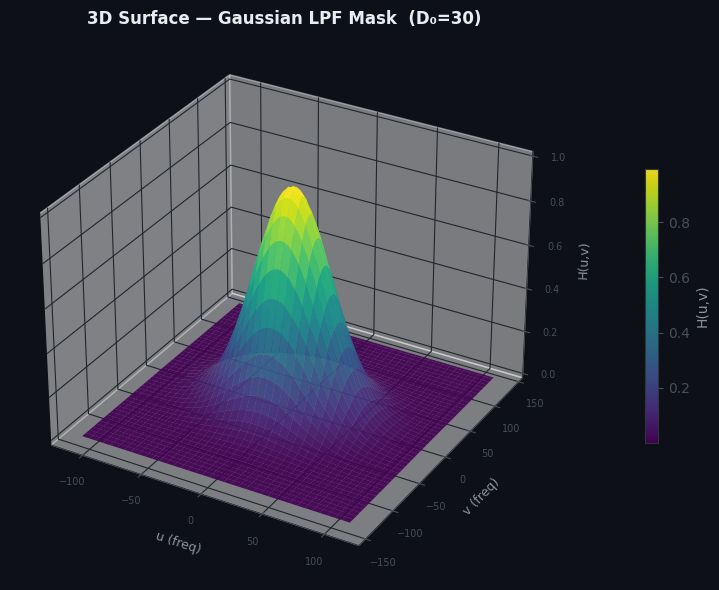

💡 Perfect bell shape — the smoothest possible LPF profile.


In [6]:
# Downsample for speed
step  = max(1, min(H, W) // 60)
m_sub = mask[::step, ::step]
ys    = (np.arange(m_sub.shape[0]) - m_sub.shape[0] // 2) * step
xs_3d = (np.arange(m_sub.shape[1]) - m_sub.shape[1] // 2) * step
XX, YY = np.meshgrid(xs_3d, ys)

fig = plt.figure(figsize=(9, 6))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')

surf = ax3d.plot_surface(XX, YY, m_sub, cmap='viridis', alpha=0.92, linewidth=0)
ax3d.set_title(f'3D Surface — Gaussian LPF Mask  (D₀={D0})', fontsize=12, fontweight='bold', color='#e6edf3')
ax3d.set_xlabel('u (freq)', color='#8b949e', fontsize=9)
ax3d.set_ylabel('v (freq)', color='#8b949e', fontsize=9)
ax3d.set_zlabel('H(u,v)',   color='#8b949e', fontsize=9)
ax3d.tick_params(colors='#484f58', labelsize=7)
fig.colorbar(surf, ax=ax3d, shrink=0.5, pad=0.1, label='H(u,v)')
plt.tight_layout()
plt.show()

print('💡 Perfect bell shape — the smoothest possible LPF profile.')

## Step 5 — Apply Mask & View Filtered Spectrum

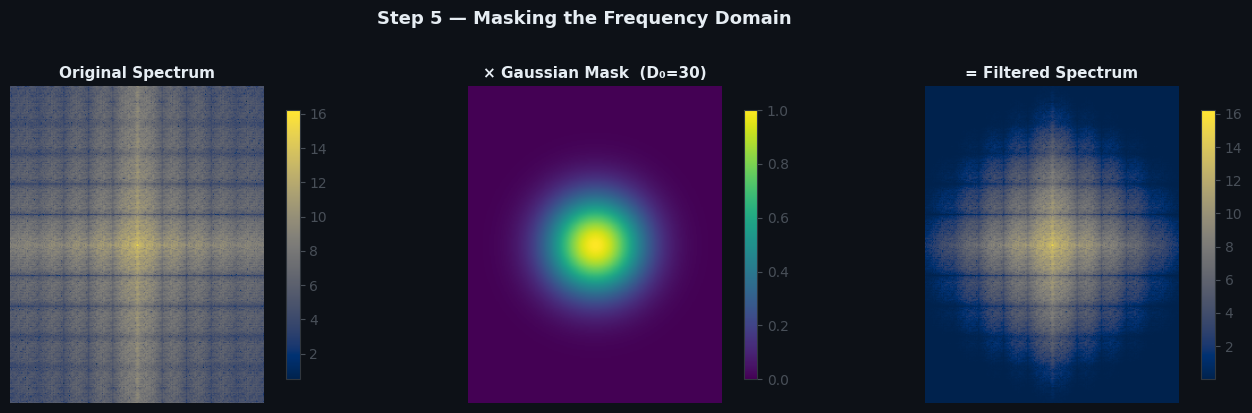

In [7]:
filtered_shift = dft_shift * mask
filtered_log   = np.log1p(np.abs(filtered_shift))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(log_mag,      cmap='cividis'); axes[0].set_title('Original Spectrum',             fontsize=11, fontweight='bold'); plt.colorbar(im0, ax=axes[0], shrink=0.85)
im1 = axes[1].imshow(mask,         cmap='viridis', vmin=0, vmax=1); axes[1].set_title(f'× Gaussian Mask  (D₀={D0})', fontsize=11, fontweight='bold'); plt.colorbar(im1, ax=axes[1], shrink=0.85)
im2 = axes[2].imshow(filtered_log, cmap='cividis'); axes[2].set_title('= Filtered Spectrum',           fontsize=11, fontweight='bold'); plt.colorbar(im2, ax=axes[2], shrink=0.85)

for ax in axes: ax.axis('off')
plt.suptitle('Step 5 — Masking the Frequency Domain', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 6 — Inverse DFT → Filtered Image

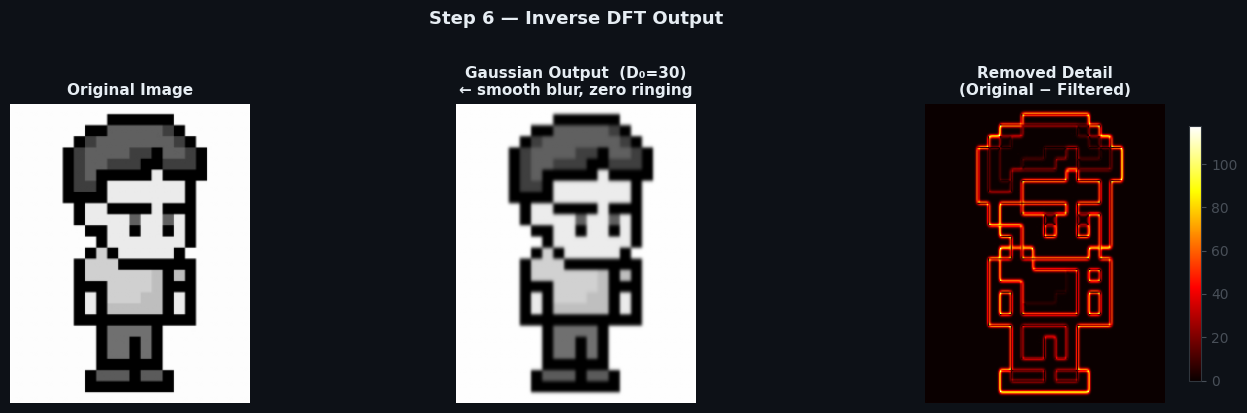

💡 Gaussian blur = the most natural-looking blur (used in photography, UI frosted glass, etc.)
💡 Zero ringing because the Gaussian function is its own Fourier transform.


In [8]:
filtered_img = np.abs(np.fft.ifft2(np.fft.ifftshift(filtered_shift)))
diff         = np.abs(img - filtered_img)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img,          cmap='gray'); axes[0].set_title('Original Image',                   fontsize=11, fontweight='bold')
axes[1].imshow(filtered_img, cmap='gray'); axes[1].set_title(f'Gaussian Output  (D₀={D0})\n← smooth blur, zero ringing', fontsize=11, fontweight='bold')
im2 = axes[2].imshow(diff,   cmap='hot');  axes[2].set_title('Removed Detail\n(Original − Filtered)', fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=axes[2], shrink=0.85)

for ax in axes: ax.axis('off')
plt.suptitle('Step 6 — Inverse DFT Output', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Gaussian blur = the most natural-looking blur (used in photography, UI frosted glass, etc.)')
print('💡 Zero ringing because the Gaussian function is its own Fourier transform.')

## Step 7 — Compare Multiple Cutoff Radii (D₀)

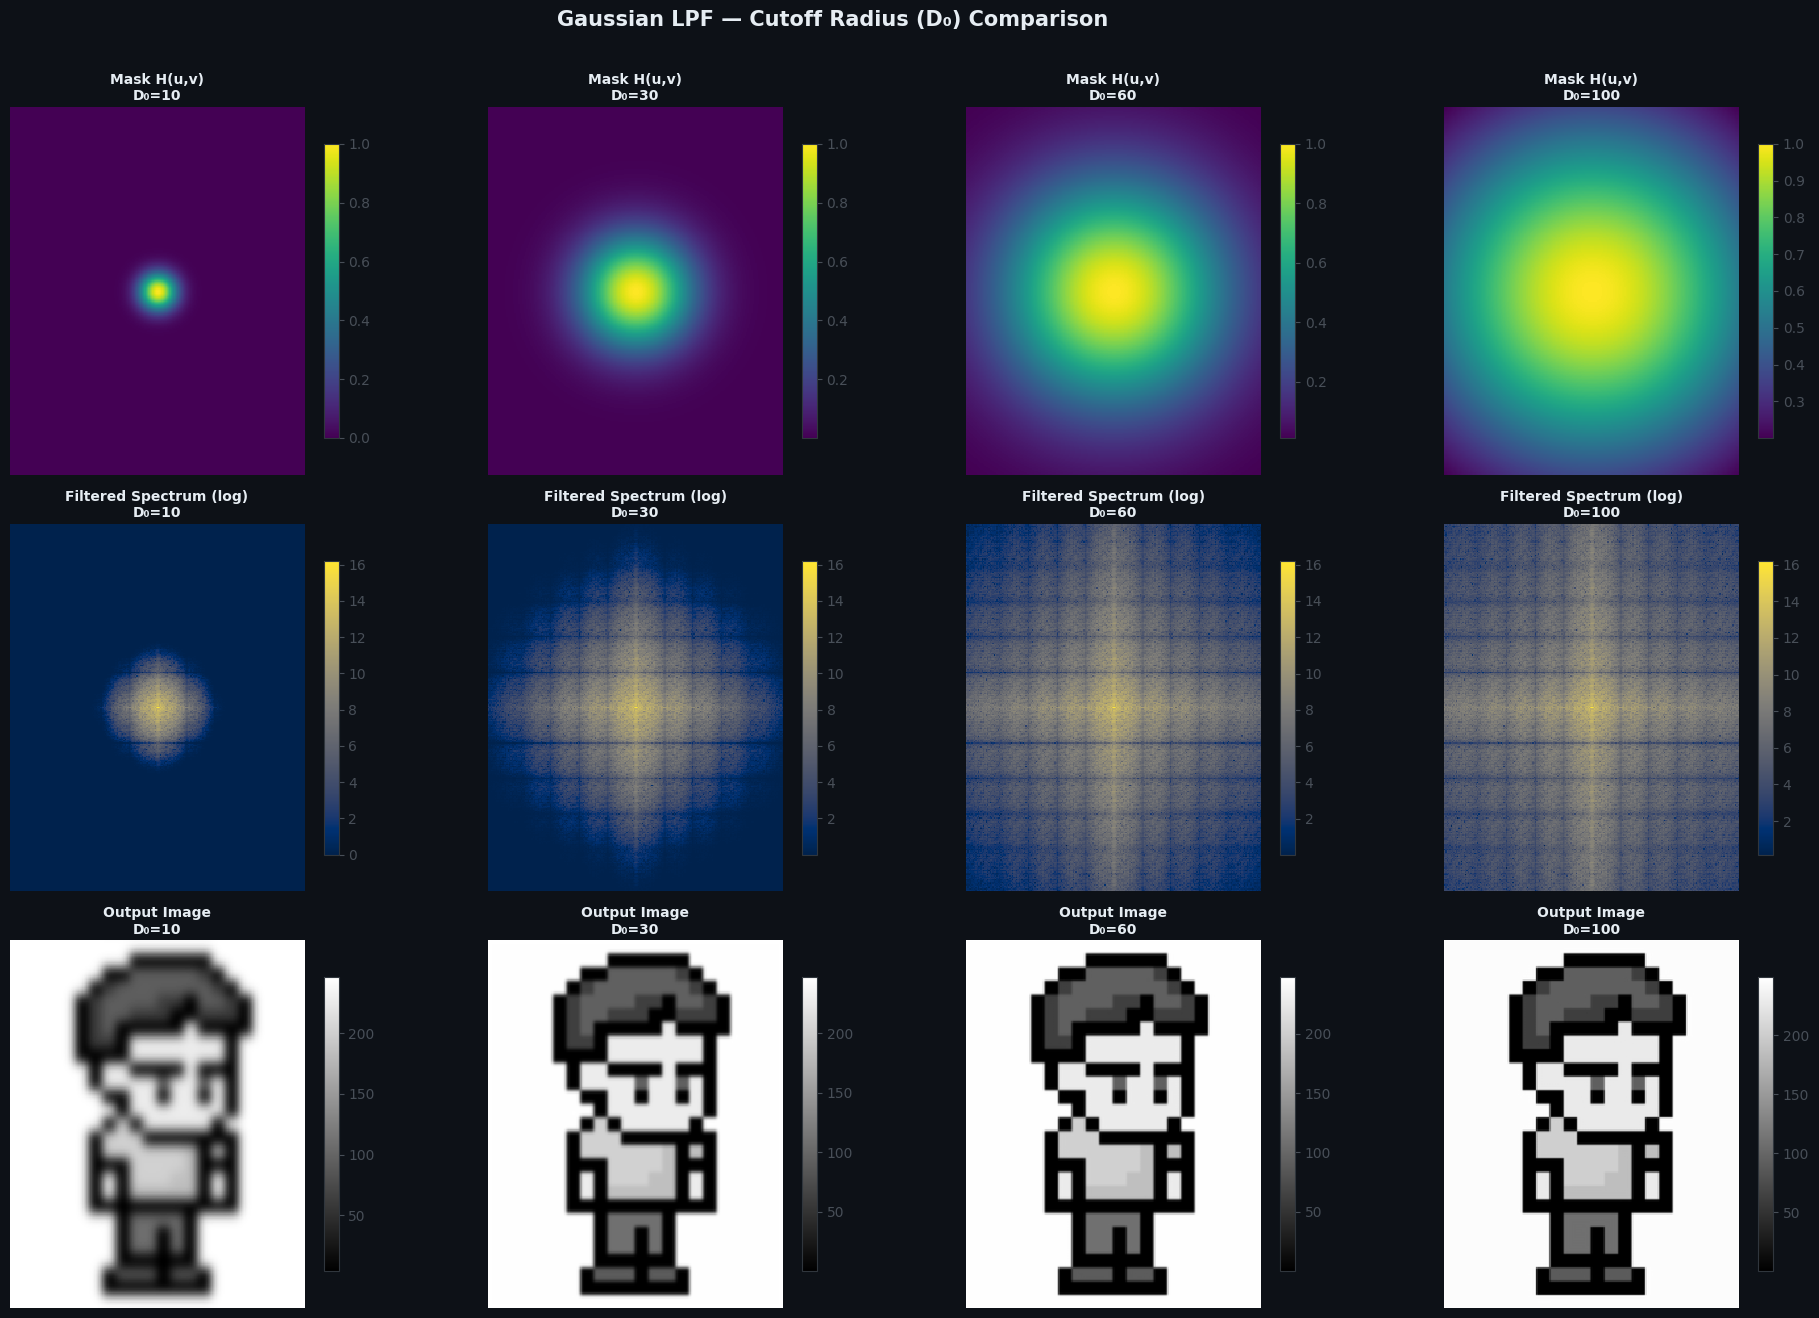

💡 Small D₀ → heavy blur (narrow Gaussian)
💡 Large D₀ → mild blur, near-original (wide Gaussian)


In [9]:
CUTOFF_RADII = [10, 30, 60, 100]

fig, axes = plt.subplots(3, len(CUTOFF_RADII), figsize=(5 * len(CUTOFF_RADII), 13))
row_labels = ['Mask H(u,v)', 'Filtered Spectrum (log)', 'Output Image']
cmaps      = ['viridis', 'cividis', 'gray']

for col, D0_val in enumerate(CUTOFF_RADII):
    m  = gaussian_lpf_mask(img.shape, D0_val)
    fs = dft_shift * m
    fi = np.abs(np.fft.ifft2(np.fft.ifftshift(fs)))

    for row, (data, cmap) in enumerate(zip([m, np.log1p(np.abs(fs)), fi], cmaps)):
        ax = axes[row, col]
        im = ax.imshow(data, cmap=cmap, interpolation='nearest')
        ax.set_title(f'{row_labels[row]}\nD₀={D0_val}', fontsize=10, fontweight='bold', pad=5)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.8)

plt.suptitle('Gaussian LPF — Cutoff Radius (D₀) Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Small D₀ → heavy blur (narrow Gaussian)')
print('💡 Large D₀ → mild blur, near-original (wide Gaussian)')

## Step 8 — Cross-Section Overlay: All D₀ Values

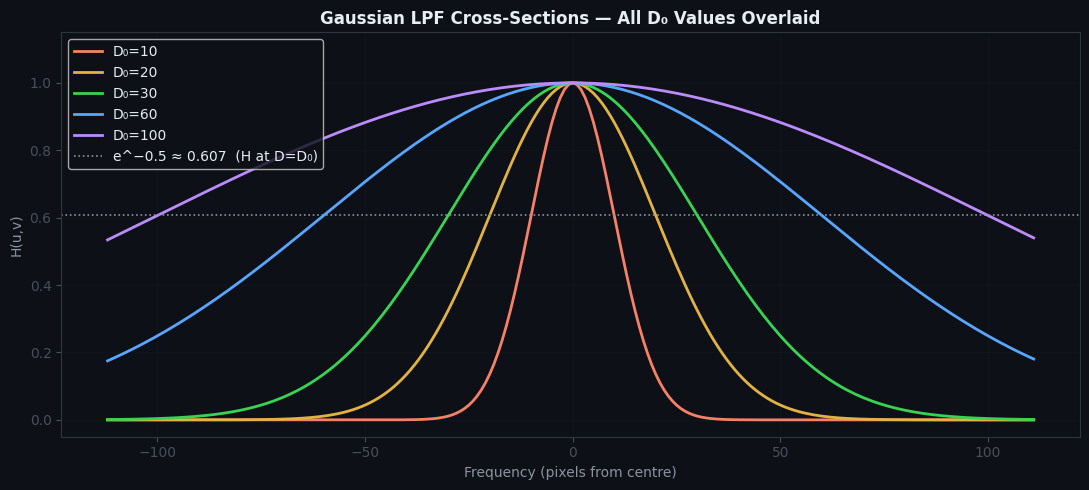

💡 Notice all curves pass through H = e^-0.5 ≈ 0.607 exactly at D=D₀.
💡 No curves ever touch 0 or 1 sharply — always a smooth bell transition.


In [10]:
CUTOFF_RADII_CS = [10, 20, 30, 60, 100]
colors_cs       = ['#f78166', '#e3b341', '#39d353', '#58a6ff', '#bc8cff']

fig, ax = plt.subplots(figsize=(11, 5))

for D0_val, color in zip(CUTOFF_RADII_CS, colors_cs):
    m   = gaussian_lpf_mask(img.shape, D0_val)
    mid = m[H // 2, :]
    xs  = np.arange(W) - W // 2
    ax.plot(xs, mid, color=color, linewidth=2, label=f'D₀={D0_val}')

ax.axhline(np.exp(-0.5), color='#8b949e', linestyle=':', linewidth=1.2,
           label=f'e^−0.5 ≈ {np.exp(-0.5):.3f}  (H at D=D₀)')
ax.set_title('Gaussian LPF Cross-Sections — All D₀ Values Overlaid', fontsize=12, fontweight='bold')
ax.set_xlabel('Frequency (pixels from centre)')
ax.set_ylabel('H(u,v)')
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print('💡 Notice all curves pass through H = e^-0.5 ≈ 0.607 exactly at D=D₀.')
print('💡 No curves ever touch 0 or 1 sharply — always a smooth bell transition.')

## Step 9 — Full 3-Filter Comparison: Ideal vs Butterworth vs Gaussian

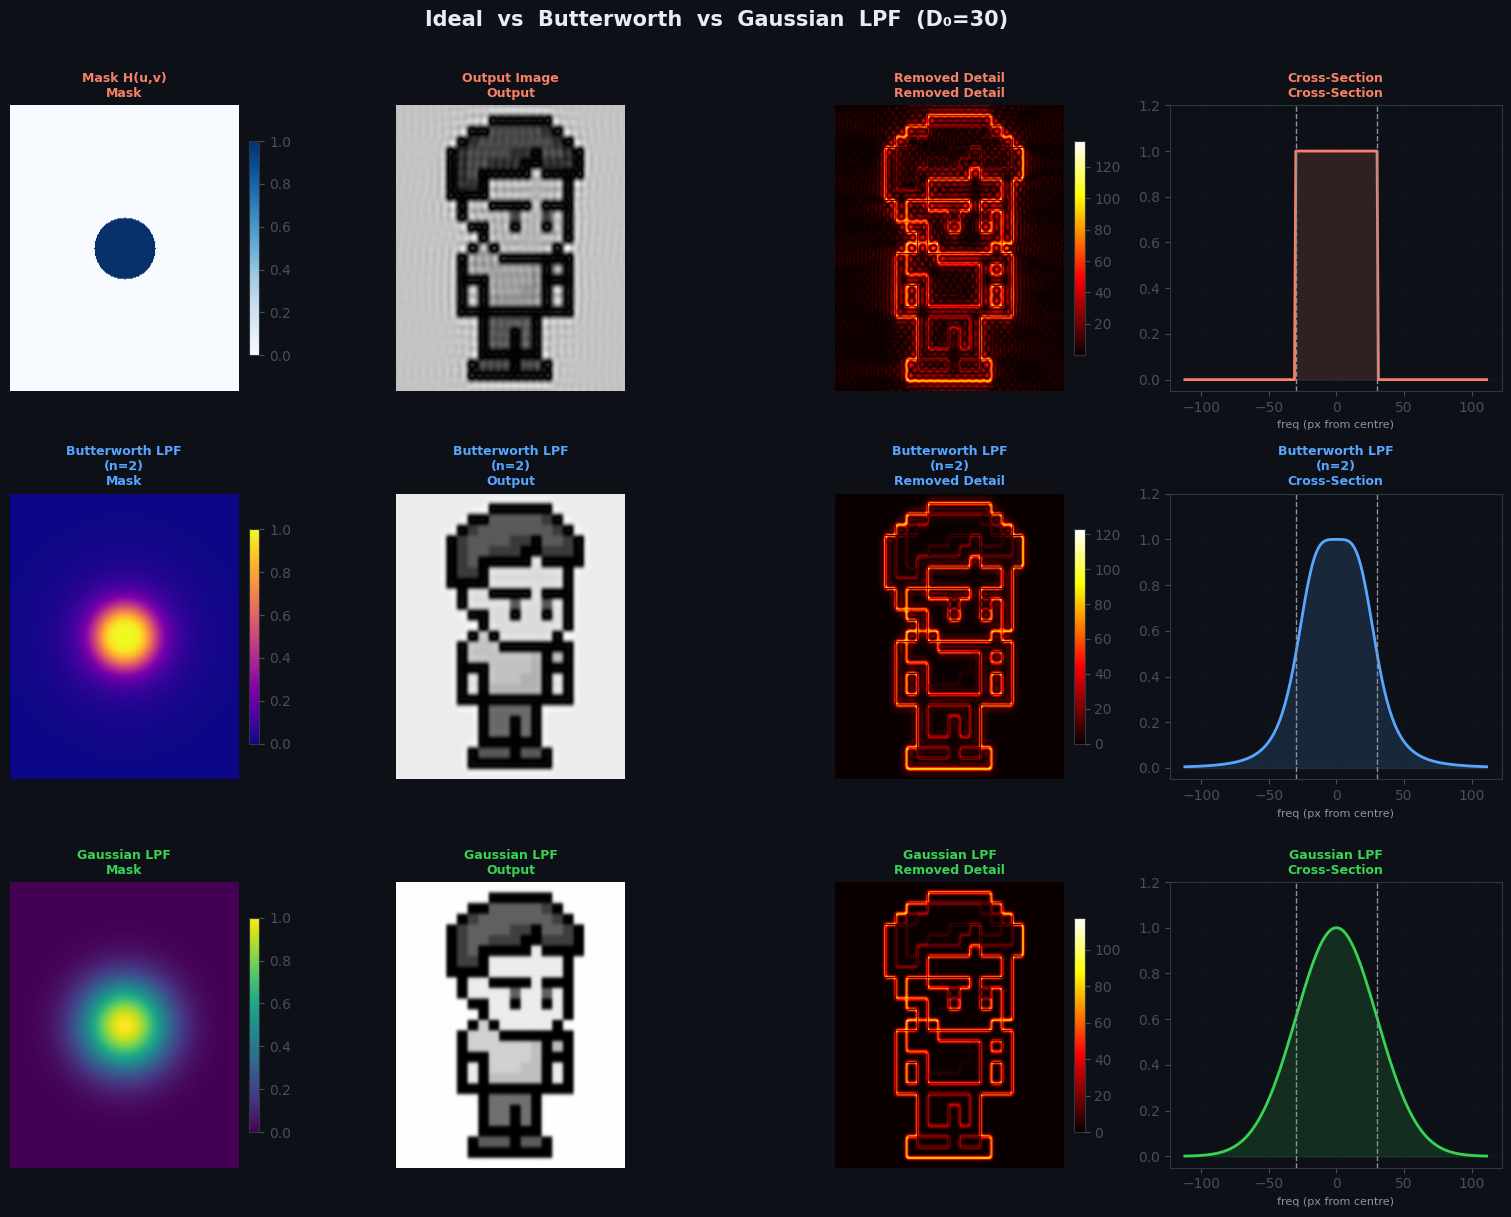

🔴  Ideal LPF       → hard cutoff → ringing (Gibbs) artifacts
🔵  Butterworth LPF → smooth roll-off, tunable sharpness via n
🟢  Gaussian LPF    → softest roll-off, zero ringing, most natural blur


In [11]:
def ideal_lpf_mask(shape, D0):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    return ((np.sqrt((X-ccol)**2 + (Y-crow)**2)) <= D0).astype(np.float32)

def butterworth_lpf_mask(shape, D0, n=2):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    D = np.sqrt((X - ccol)**2 + (Y - crow)**2)
    return (1 / (1 + (D / D0) ** (2 * n))).astype(np.float32)

D0_cmp = 30

masks   = [ideal_lpf_mask(img.shape, D0_cmp),
           butterworth_lpf_mask(img.shape, D0_cmp, n=2),
           gaussian_lpf_mask(img.shape, D0_cmp)]
outputs = [np.abs(np.fft.ifft2(np.fft.ifftshift(dft_shift * m))) for m in masks]
diffs   = [np.abs(img - o) for o in outputs]
labels  = ['Ideal LPF', 'Butterworth LPF\n(n=2)', 'Gaussian LPF']
mask_cmaps = ['Blues', 'plasma', 'viridis']

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
col_titles = ['Mask H(u,v)', 'Output Image', 'Removed Detail', 'Cross-Section']

xs = np.arange(W) - W // 2
filter_colors = ['#f78166', '#58a6ff', '#39d353']

for row, (m, out, diff, label, mc, fc) in enumerate(
        zip(masks, outputs, diffs, labels, mask_cmaps, filter_colors)):

    # Col 0: mask
    im0 = axes[row,0].imshow(m, cmap=mc, vmin=0, vmax=1)
    axes[row,0].set_title(f'{label}\nMask', fontsize=9, fontweight='bold', color=fc)
    axes[row,0].axis('off')
    plt.colorbar(im0, ax=axes[row,0], shrink=0.75, fraction=0.046, pad=0.03)

    # Col 1: output
    axes[row,1].imshow(out, cmap='gray')
    axes[row,1].set_title(f'{label}\nOutput', fontsize=9, fontweight='bold', color=fc)
    axes[row,1].axis('off')

    # Col 2: diff
    im2 = axes[row,2].imshow(diff, cmap='hot')
    axes[row,2].set_title(f'{label}\nRemoved Detail', fontsize=9, fontweight='bold', color=fc)
    axes[row,2].axis('off')
    plt.colorbar(im2, ax=axes[row,2], shrink=0.75, fraction=0.046, pad=0.03)

    # Col 3: cross-section
    mid = m[H // 2, :]
    axes[row,3].plot(xs, mid, color=fc, linewidth=2)
    axes[row,3].axvline( D0_cmp, color='#8b949e', linestyle='--', linewidth=1)
    axes[row,3].axvline(-D0_cmp, color='#8b949e', linestyle='--', linewidth=1)
    axes[row,3].fill_between(xs, mid, alpha=0.15, color=fc)
    axes[row,3].set_title(f'{label}\nCross-Section', fontsize=9, fontweight='bold', color=fc)
    axes[row,3].set_ylim(-0.05, 1.2)
    axes[row,3].set_xlabel('freq (px from centre)', fontsize=8)
    axes[row,3].grid(alpha=0.2)

# Column headers
for c, ct in enumerate(col_titles):
    axes[0, c].set_title(f'{ct}\n' + axes[0,c].get_title().split('\n')[1],
                         fontsize=9, fontweight='bold', color=filter_colors[0])

plt.suptitle(f'Ideal  vs  Butterworth  vs  Gaussian  LPF  (D₀={D0_cmp})',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('🔴  Ideal LPF       → hard cutoff → ringing (Gibbs) artifacts')
print('🔵  Butterworth LPF → smooth roll-off, tunable sharpness via n')
print('🟢  Gaussian LPF    → softest roll-off, zero ringing, most natural blur')

## Step 10 — Filter Profile Comparison Chart (1D Overlay)

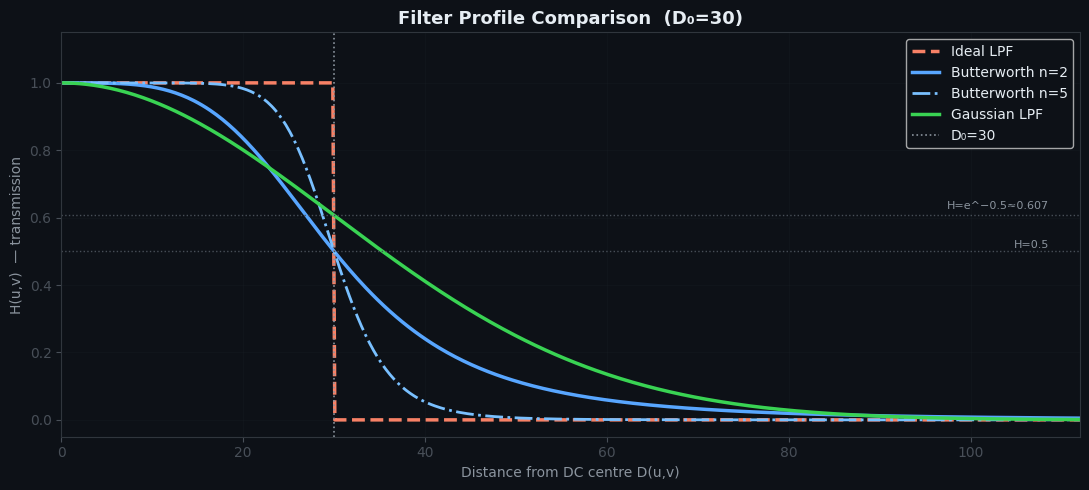

💡 All three filters pass the same DC (zero freq) and block the same extreme high freqs.
💡 They differ only in how gradually they transition between pass and stop.


In [12]:
D0_plot = 30
xs_plot = np.linspace(0, W // 2, 500)

ideal_h    = (xs_plot <= D0_plot).astype(float)
butter2_h  = 1 / (1 + (xs_plot / D0_plot) ** (2 * 2))
butter5_h  = 1 / (1 + (xs_plot / D0_plot) ** (2 * 5))
gauss_h    = np.exp(-(xs_plot**2) / (2 * D0_plot**2))

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(xs_plot, ideal_h,   color='#f78166', linewidth=2.5, linestyle='--',  label='Ideal LPF')
ax.plot(xs_plot, butter2_h, color='#58a6ff', linewidth=2.5,                  label='Butterworth n=2')
ax.plot(xs_plot, butter5_h, color='#79c0ff', linewidth=2,   linestyle='-.',  label='Butterworth n=5')
ax.plot(xs_plot, gauss_h,   color='#39d353', linewidth=2.5,                  label='Gaussian LPF')

ax.axvline(D0_plot, color='#8b949e', linestyle=':', linewidth=1.2, label=f'D₀={D0_plot}')
ax.axhline(0.5,     color='#484f58', linestyle=':', linewidth=1.0)
ax.axhline(np.exp(-0.5), color='#484f58', linestyle=':', linewidth=1.0)
ax.text(W//2 * 0.97, 0.51,        'H=0.5',         ha='right', fontsize=8, color='#8b949e')
ax.text(W//2 * 0.97, np.exp(-0.5)+0.02, 'H=e^−0.5≈0.607', ha='right', fontsize=8, color='#8b949e')

ax.set_title(f'Filter Profile Comparison  (D₀={D0_plot})', fontsize=13, fontweight='bold')
ax.set_xlabel('Distance from DC centre D(u,v)')
ax.set_ylabel('H(u,v)  — transmission')
ax.set_xlim(0, W // 2)
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print('💡 All three filters pass the same DC (zero freq) and block the same extreme high freqs.')
print('💡 They differ only in how gradually they transition between pass and stop.')

## Step 11 — Interactive: Try Your Own D₀

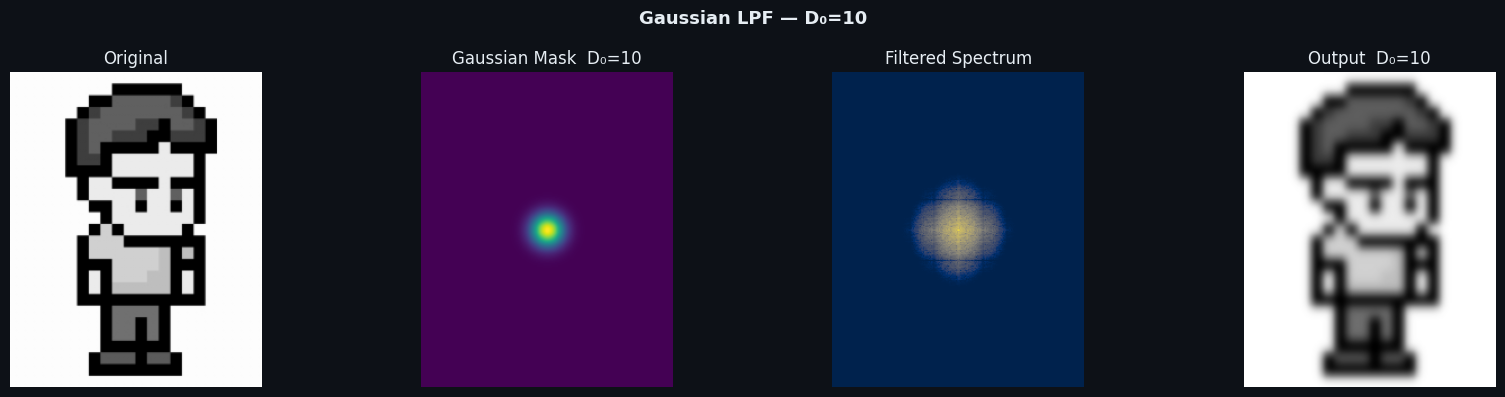

In [16]:
# ── Change D0_custom and re-run ─────────────────────────────
D0_custom = 10    # cutoff radius (try: 5, 15, 40, 80, 120)
# ────────────────────────────────────────────────────────────

m_c  = gaussian_lpf_mask(img.shape, D0_custom)
fs_c = dft_shift * m_c
fi_c = np.abs(np.fft.ifft2(np.fft.ifftshift(fs_c)))

fig, axes = plt.subplots(1, 4, figsize=(17, 4))

axes[0].imshow(img,                      cmap='gray');    axes[0].set_title('Original')
axes[1].imshow(m_c,                      cmap='viridis'); axes[1].set_title(f'Gaussian Mask  D₀={D0_custom}')
axes[2].imshow(np.log1p(np.abs(fs_c)),   cmap='cividis'); axes[2].set_title('Filtered Spectrum')
axes[3].imshow(fi_c,                     cmap='gray');    axes[3].set_title(f'Output  D₀={D0_custom}')

for ax in axes: ax.axis('off')
plt.suptitle(f'Gaussian LPF — D₀={D0_custom}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()